In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('car_price_prediction_.csv')
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


# EDA

In [3]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [4]:
df.shape

(2500, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [6]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [7]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [8]:
df.columns

Index(['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission',
       'Mileage', 'Condition', 'Price', 'Model'],
      dtype='object')

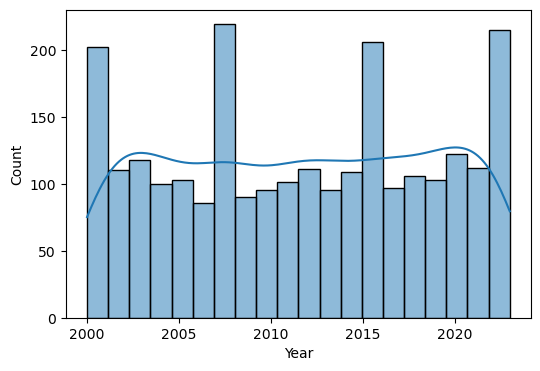

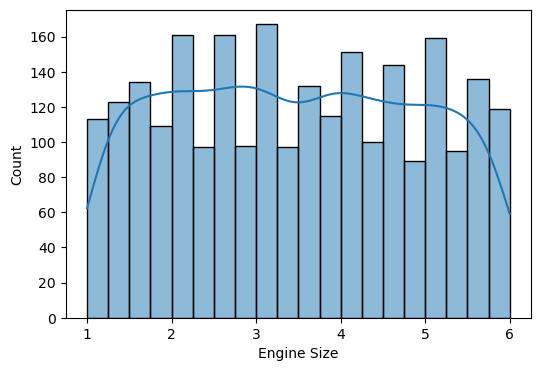

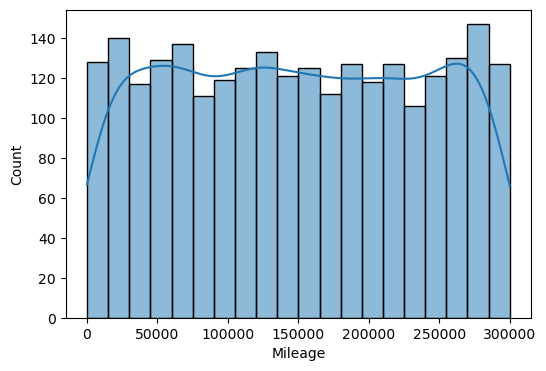

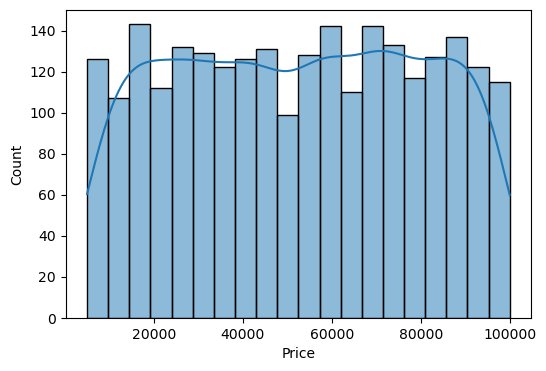

In [9]:
num_col = ['Year', 'Engine Size', 'Mileage', 'Price']
for col in num_col:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col], kde=True, bins=20)

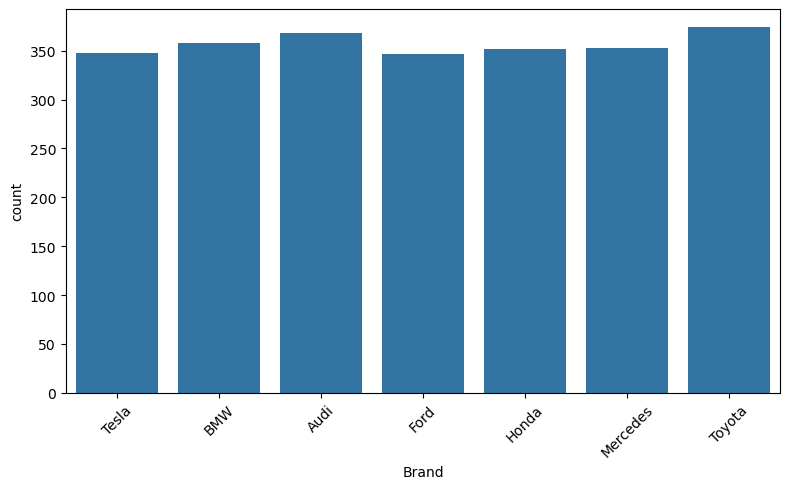

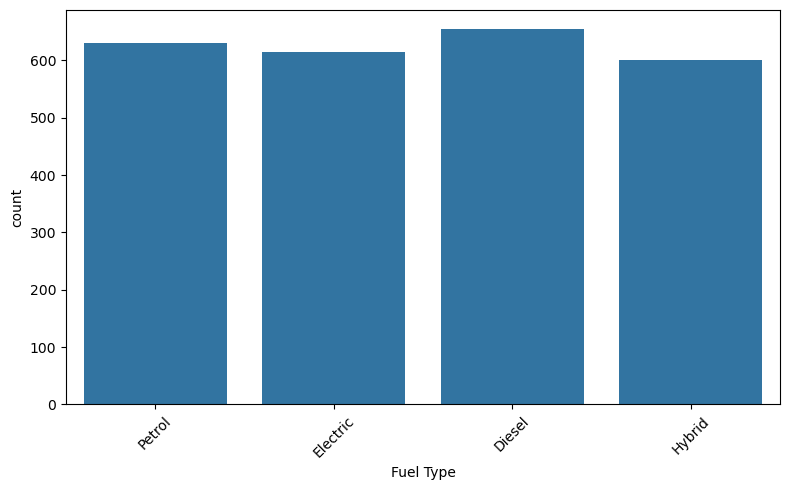

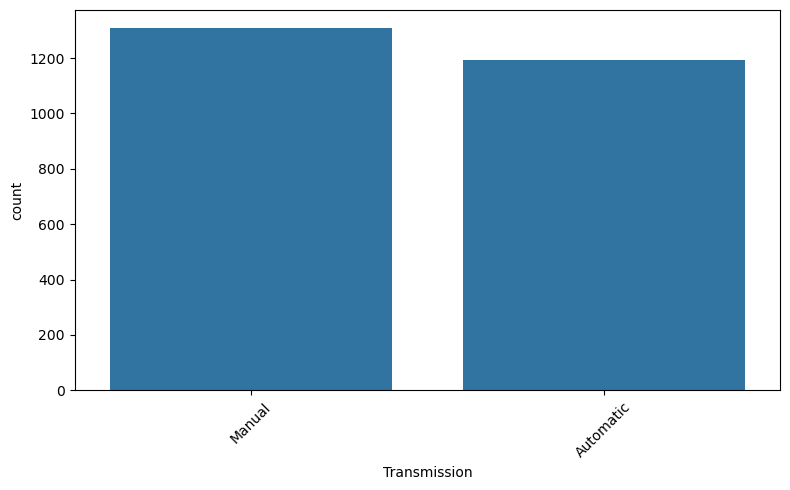

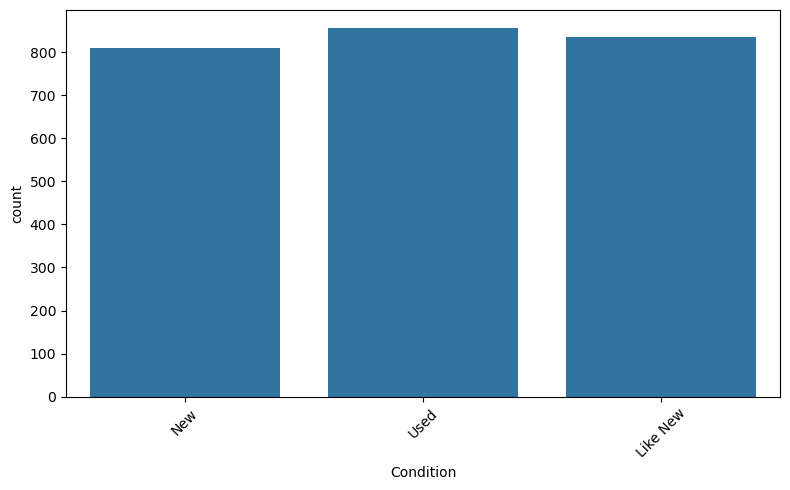

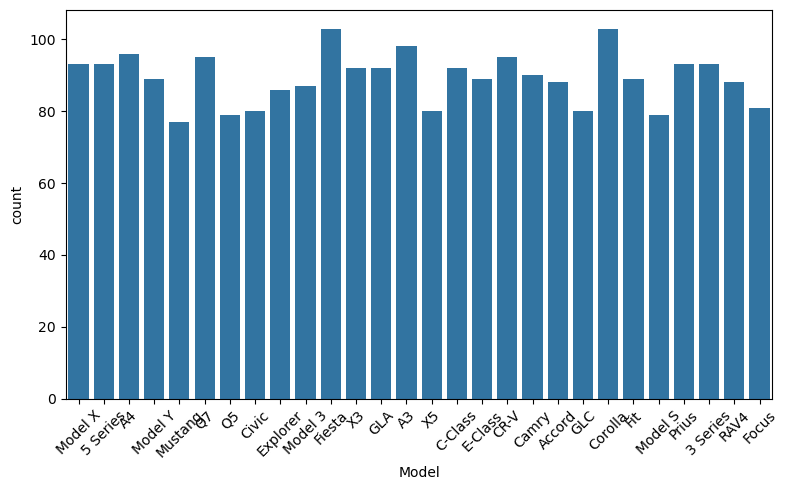

In [10]:
cat_col = ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']
for col in cat_col:
    plt.figure(figsize=(8,5))
    sns.countplot(x = df[col])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

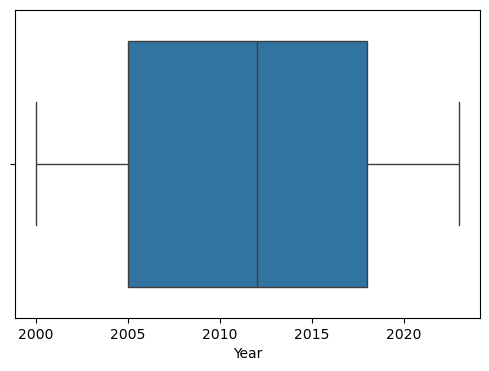

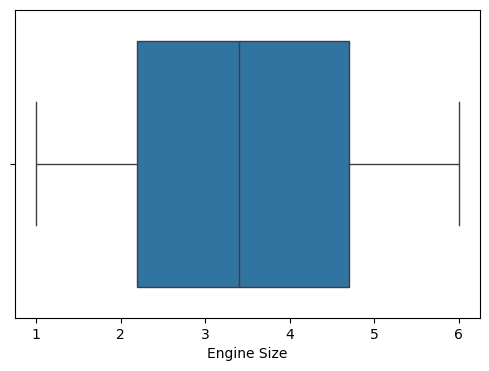

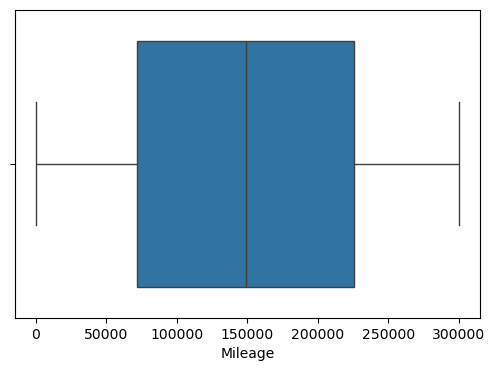

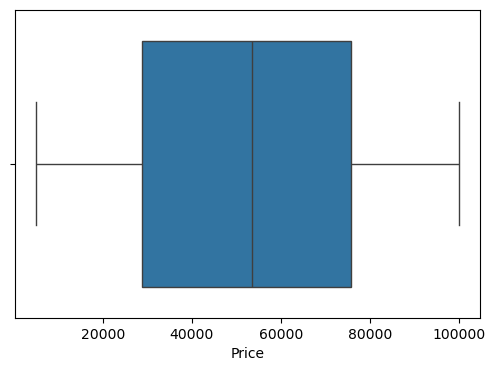

In [11]:
for col in num_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

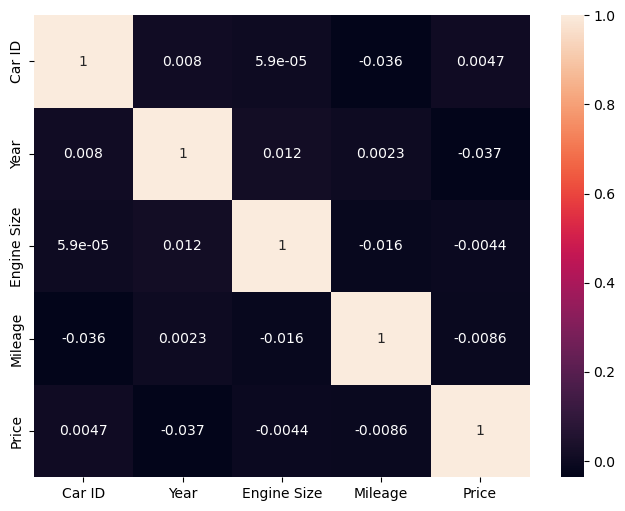

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Cleaning and Preprocessing

In [13]:
df_cleaned = df.copy()

In [14]:
df_cleaned.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [15]:
df_cleaned.drop(columns='Car ID', inplace=True)
df_cleaned.head()

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [16]:
df_cleaned.dtypes

Brand            object
Year              int64
Engine Size     float64
Fuel Type        object
Transmission     object
Mileage           int64
Condition        object
Price           float64
Model            object
dtype: object

In [17]:
df_cleaned['Transmission'].value_counts()

Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

In [18]:
df_cleaned['Transmission'] = df_cleaned['Transmission'].map({'Manual': 0, 'Automatic': 1})

In [19]:
df_cleaned.rename(columns={'Transmission': 'is_Automatic'}, inplace=True)
df_cleaned.head()

,Brand,Year,Engine Size,Fuel Type,is_Automatic,Mileage,Condition,Price,Model
0,Tesla,2016,2.3,Petrol,0,114832,New,26613.92,Model X
1,BMW,2018,4.4,Electric,0,143190,Used,14679.61,5 Series
2,Audi,2013,4.5,Electric,0,181601,New,44402.61,A4
3,Tesla,2011,4.1,Diesel,1,68682,New,86374.33,Model Y
4,Ford,2009,2.6,Diesel,0,223009,Like New,73577.10,Mustang


In [20]:
df_cleaned['Brand'].value_counts() 

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

In [21]:
df_cleaned['Fuel Type'].value_counts()

Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

In [22]:
df_cleaned['Condition'].value_counts()

Condition
Used        855
Like New    836
New         809
Name: count, dtype: int64

In [23]:
df_cleaned['Model'].value_counts()

Model
Fiesta      103
Corolla     103
A3           98
A4           96
Q7           95
CR-V         95
5 Series     93
3 Series     93
Prius        93
Model X      93
C-Class      92
X3           92
GLA          92
Camry        90
E-Class      89
Fit          89
Model Y      89
RAV4         88
Accord       88
Model 3      87
Explorer     86
Focus        81
Civic        80
X5           80
GLC          80
Q5           79
Model S      79
Mustang      77
Name: count, dtype: int64

In [24]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['Brand', 'Fuel Type', 'Condition', 'Model'], drop_first=True)

In [25]:
df_cleaned

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,...,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,2016,2.3,0,114832,26613.92,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
1,2018,4.4,0,143190,14679.61,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2013,4.5,0,181601,44402.61,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2011,4.1,1,68682,86374.33,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,False
4,2009,2.6,0,223009,73577.10,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2020,2.4,1,22650,61384.10,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2496,2001,5.7,0,77701,24710.35,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2497,2021,1.1,0,272827,29902.45,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2498,2002,4.5,0,229164,46085.67,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [26]:
df_cleaned = df_cleaned.astype(int)

In [27]:
pd.set_option('display.max_columns', None)
df_cleaned.head()

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5
0,2016,2,0,114832,26613,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,2018,4,0,143190,14679,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2013,4,0,181601,44402,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2011,4,1,68682,86374,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,2009,2,0,223009,73577,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


# Feature Engineering and Extraction 

In [28]:
from datetime import datetime 
df_cleaned['Car_Age'] = datetime.now().year - df_cleaned['Year']

In [29]:
df_cleaned

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5,Car_Age
0,2016,2,0,114832,26613,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,10
1,2018,4,0,143190,14679,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8
2,2013,4,0,181601,44402,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13
3,2011,4,1,68682,86374,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,15
4,2009,2,0,223009,73577,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2020,2,1,22650,61384,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6
2496,2001,5,0,77701,24710,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25
2497,2021,1,0,272827,29902,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5
2498,2002,4,0,229164,46085,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,24


In [30]:
df_cleaned['Mileage_per_Year'] = (
    df_cleaned['Mileage'] / df_cleaned['Car_Age']
)

In [31]:
df_cleaned.head()

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5,Car_Age,Mileage_per_Year
0,2016,2,0,114832,26613,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,10,11483.200000
1,2018,4,0,143190,14679,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,17898.750000
2,2013,4,0,181601,44402,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,13969.307692
3,2011,4,1,68682,86374,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,15,4578.800000
4,2009,2,0,223009,73577,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,17,13118.176471


In [32]:
df_cleaned['Engine_Category'] = pd.cut(
    df_cleaned['Engine Size'],
    bins=[0,1.5,2.5,10],
    labels=['Small','Medium','Large']
)
df_cleaned.head()

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5,Car_Age,Mileage_per_Year,Engine_Category
0,2016,2,0,114832,26613,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,10,11483.200000,Medium
1,2018,4,0,143190,14679,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,17898.750000,Large
2,2013,4,0,181601,44402,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,13969.307692,Large
3,2011,4,1,68682,86374,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,15,4578.800000,Large
4,2009,2,0,223009,73577,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,17,13118.176471,Medium


In [33]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['Engine_Category'], drop_first=True)
df_cleaned = df_cleaned.astype(int)

In [34]:
df_cleaned

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5,Car_Age,Mileage_per_Year,Engine_Category_Medium,Engine_Category_Large
0,2016,2,0,114832,26613,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,10,11483,1,0
1,2018,4,0,143190,14679,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,17898,0,1
2,2013,4,0,181601,44402,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,13969,0,1
3,2011,4,1,68682,86374,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,15,4578,0,1
4,2009,2,0,223009,73577,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,17,13118,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2020,2,1,22650,61384,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6,3775,1,0
2496,2001,5,0,77701,24710,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,3108,0,1
2497,2021,1,0,272827,29902,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,54565,0,0
2498,2002,4,0,229164,46085,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,24,9548,0,1


In [35]:
from sklearn.preprocessing import StandardScaler
col = ['Year', 'Engine Size', 'Mileage', 'Car_Age', 'Mileage_per_Year']
scaler = StandardScaler()
df_cleaned[col] = scaler.fit_transform(df_cleaned[col])
df_cleaned

,Year,Engine Size,is_Automatic,Mileage,Price,Brand_BMW,Brand_Ford,Brand_Honda,Brand_Mercedes,Brand_Tesla,Brand_Toyota,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_Petrol,Condition_New,Condition_Used,Model_5 Series,Model_A3,Model_A4,Model_Accord,Model_C-Class,Model_CR-V,Model_Camry,Model_Civic,Model_Corolla,Model_E-Class,Model_Explorer,Model_Fiesta,Model_Fit,Model_Focus,Model_GLA,Model_GLC,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Model_Mustang,Model_Prius,Model_Q5,Model_Q7,Model_RAV4,Model_X3,Model_X5,Car_Age,Mileage_per_Year,Engine_Category_Medium,Engine_Category_Large
0,0.625610,-0.716326,0,-0.397234,26613,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,-0.625610,-0.225619,1,0
1,0.911720,0.687134,0,-0.074626,14679,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.911720,0.189993,0,1
2,0.196444,0.687134,0,0.362347,44402,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.196444,-0.064557,0,1
3,-0.089667,0.687134,1,-0.922249,86374,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0.089667,-0.672977,0,1
4,-0.375778,-0.716326,0,0.833415,73577,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.375778,-0.119691,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,1.197831,-0.716326,1,-1.445921,61384,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,-1.197831,-0.725002,1,0
2496,-1.520220,1.388864,0,-0.819646,24710,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.520220,-0.768215,0,1
2497,1.340886,-1.418056,0,1.400157,29902,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.340886,2.565559,0,0
2498,-1.377165,0.687134,0,0.903436,46085,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1.377165,-0.350983,0,1


#### Scaling is applied because many machine learning algorithms perform better when numerical features have similar ranges.

In [36]:
from scipy.stats import pearsonr 
cont_col = ['Year', 'Engine Size', 'Mileage', 'Car_Age', 'Mileage_per_Year']

corr = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['Price'])[0]
    for feature in cont_col
}

df_corr = pd.DataFrame(list(corr.items()), columns=['Features', 'Pearson Correlation'])
df_corr = df_corr.sort_values(by = 'Pearson Correlation')
df_corr

,Features,Pearson Correlation
4,Mileage_per_Year,-0.043489
0,Year,-0.036805
2,Mileage,-0.008568
1,Engine Size,-0.005776
3,Car_Age,0.036805


In [37]:
from scipy.stats import chi2_contingency
cat_col= ['is_Automatic', 'Brand_BMW',
       'Brand_Ford', 'Brand_Honda', 'Brand_Mercedes', 'Brand_Tesla',
       'Brand_Toyota', 'Fuel Type_Electric', 'Fuel Type_Hybrid',
       'Fuel Type_Petrol', 'Condition_New', 'Condition_Used', 'Model_5 Series',
       'Model_A3', 'Model_A4', 'Model_Accord', 'Model_C-Class', 'Model_CR-V',
       'Model_Camry', 'Model_Civic', 'Model_Corolla', 'Model_E-Class',
       'Model_Explorer', 'Model_Fiesta', 'Model_Fit', 'Model_Focus',
       'Model_GLA', 'Model_GLC', 'Model_Model 3', 'Model_Model S',
       'Model_Model X', 'Model_Model Y', 'Model_Mustang', 'Model_Prius',
       'Model_Q5', 'Model_Q7', 'Model_RAV4', 'Model_X3', 'Model_X5', 
       'Engine_Category_Medium', 'Engine_Category_Large']

df_cleaned['Price_Category'] = pd.qcut(df_cleaned['Price'], q = 4, labels = False)

alpha = 0.05
chi2_results = {}
for col in cat_col:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['Price_Category'])
    chi2, p_val, _, _ = chi2_contingency(contingency_table)
    decision = 'Reject null (keep Feature)' if p_val<alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2': chi2,
        'p_value': p_val,
        'Decision': decision
    }

chi2_results = pd.DataFrame(chi2_results).T
chi2_results = chi2_results.sort_values(by = 'p_value')
chi2_results

,chi2,p_value,Decision
Model_GLC,11.880165,0.007805,Reject null (keep Feature)
Brand_BMW,11.645254,0.008703,Reject null (keep Feature)
Engine_Category_Medium,10.327142,0.015981,Reject null (keep Feature)
Model_Q5,6.104288,0.106645,Accept Null (Drop Feature)
Model_Mustang,4.8641,0.182023,Accept Null (Drop Feature)
Model_Prius,4.590107,0.204392,Accept Null (Drop Feature)
Model_Model Y,4.508829,0.211504,Accept Null (Drop Feature)
Brand_Mercedes,4.46964,0.215014,Accept Null (Drop Feature)
Fuel Type_Electric,3.825548,0.280928,Accept Null (Drop Feature)
Model_Model X,3.786001,0.285519,Accept Null (Drop Feature)


In [39]:
final_df = df_cleaned[['Engine Size', 'Mileage_per_Year', 'Car_Age', 'Price', 'Model_GLC', 'Brand_BMW', 'Engine_Category_Medium']]
final_df

,Engine Size,Mileage_per_Year,Car_Age,Price,Model_GLC,Brand_BMW,Engine_Category_Medium
0,-0.716326,-0.225619,-0.625610,26613,0,0,1
1,0.687134,0.189993,-0.911720,14679,0,1,0
2,0.687134,-0.064557,-0.196444,44402,0,0,0
3,0.687134,-0.672977,0.089667,86374,0,0,0
4,-0.716326,-0.119691,0.375778,73577,0,0,1
...,...,...,...,...,...,...,...
2495,-0.716326,-0.725002,-1.197831,61384,0,0,1
2496,1.388864,-0.768215,1.520220,24710,0,0,0
2497,-1.418056,2.565559,-1.340886,29902,0,0,0
2498,0.687134,-0.350983,1.377165,46085,0,0,0


## Final Interpretation and Dataset Insight

The Chi-square tests identified only a small number of significant features. However, approximately 40 tests were performed at a significance level of α = 0.05. When many tests are conducted simultaneously, some features may appear significant purely by chance.

Expected false positives by chance:

40 × 0.05 = 2

The analysis identified only 3 significant features, which is very close to the number expected due to random chance alone. Therefore, these results cannot be confidently interpreted as strong evidence of meaningful relationships within the data.

Based on the Pearson correlation and Chi-square analysis, the following conclusions can be made:

- The multiple testing problem increases the risk of false positive results.
- The identified significant features may not represent true predictive signals.
- Weak Pearson correlations and weak Chi-square results suggest limited relationships between features and the target variable (`Price`).
- The dataset may contain synthetic or randomly generated target values rather than strong real-world patterns.
- Feature selection results should be interpreted carefully, and modeling should be treated primarily as a learning exercise rather than assuming high predictive accuracy.

Overall conclusion:

The dataset description suggests that variables such as brand, year, engine size, fuel type, mileage, and condition should meaningfully influence car prices. However, the statistical analysis performed in this notebook showed very weak Pearson correlations for numerical features and very limited evidence of significant relationships among categorical features. This creates a contradiction between the expected behavior described for the dataset and the patterns observed in the data. Based on the current analysis, the most defensible conclusion is not that the dataset is necessarily synthetic or incorrect, but that the available features do not show strong measurable relationships with the target variable (`Price`) in this dataset. Therefore, any significant findings should be interpreted cautiously, and model performance should be evaluated carefully rather than assuming strong predictive structure exists.

# Split the dataset 

In [40]:
X = final_df.drop('Price', axis=1)
y = final_df['Price']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2000, 6)
(500, 6)
(2000,)
(500,)


In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [45]:
model.fit(X_train, y_train)

LinearRegression()

In [46]:
print(model.intercept_)
print(model.coef_)

51722.6139713047
[-248.86420643 -873.86115396  569.5814989  8897.28625166 2747.12547103
  145.79888712]


In [47]:
print(X.columns)

Index(['Engine Size', 'Mileage_per_Year', 'Car_Age', 'Model_GLC', 'Brand_BMW',
       'Engine_Category_Medium'],
      dtype='object')


In [48]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[51956.43067192 51539.41625207 52045.13323995 52474.6230689
 54231.41344606 49306.56373018 54259.2775155  54952.10394696
 54927.82458478 52140.19554742]


In [49]:
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0         17494     51956.430672
1         75919     51539.416252
2         87474     52045.133240
3         13522     52474.623069
4         77070     54231.413446
5         40085     49306.563730
6         47196     54259.277515
7         58558     54952.103947
8         23029     54927.824585
9         32351     52140.195547


In [50]:
comparison['Residual'] = (
    comparison['Actual Price'] - comparison['Predicted Price']
)

print(comparison.head(10))

   Actual Price  Predicted Price      Residual
0         17494     51956.430672 -34462.430672
1         75919     51539.416252  24379.583748
2         87474     52045.133240  35428.866760
3         13522     52474.623069 -38952.623069
4         77070     54231.413446  22838.586554
5         40085     49306.563730  -9221.563730
6         47196     54259.277515  -7063.277515
7         58558     54952.103947   3605.896053
8         23029     54927.824585 -31898.824585
9         32351     52140.195547 -19789.195547


In [51]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 759065554.8529714


In [52]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: -0.0019946671639348157


In [53]:
n = X_test.shape[0]   # number of test observations
p = X_test.shape[1]   # number of features

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Adjusted R²:", adjusted_r2)

Adjusted R²: -0.01418932842759335


In [54]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)

Training R²: 0.006459590903071799
Testing R²: -0.0019946671639348157


## Final Model Evaluation

- **R²:** I got an R² of **-0.00199** on the test data.

- **What negative R² means:** A negative R² means that my Linear Regression model performs slightly worse than simply predicting the average car price for every car. This shows that the model is not capturing the important patterns in the data effectively.

- **Connection to feature selection:** During feature selection, I found that **ALL numeric features had near-zero Pearson correlations with Price (all below 0.05)**, and Chi-square tests on categorical features produced only **3 significant results out of 40 tests**, which is consistent with random chance at α = 0.05. The negative R² directly confirms these findings.

- **What I would do with a better dataset:** With a better dataset, I would first verify that the target variable was generated from **real-world pricing data rather than synthetically**. I would then check correlations before committing to feature engineering, and consider **non-linear models like Random Forest** if linear relationships are weak.